<a href="https://colab.research.google.com/github/bimaadiwijaya8/-ML_05_Bima-Adiwijaya/blob/main/JS06/JS06-02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
	# import library
	import numpy as np
	import matplotlib.pyplot as plt
	from scipy import stats
	import seaborn as sns
	from sklearn.svm import SVC

In [2]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 32.1 MB/s eta 0:00:00


In [5]:
# buat sebuah fungsi untuk menampilkan fitting data

def plot_svc_decision_function(model, ax=None, plot_support=True):

    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # buat grid untuk evaluasi model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot batas dan margin
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

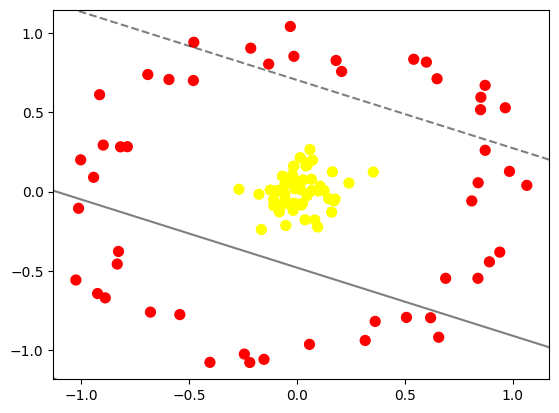

In [4]:
	# contoh data tidak terpisah secara linier
	from sklearn.datasets import make_circles
	X, y = make_circles(100, factor=.1, noise=.1)

	clf = SVC(kernel='linear').fit(X, y)

	plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
	plot_svc_decision_function(clf, plot_support=False);

In [6]:
r = np.exp(-(X**2).sum(1))

In [7]:
	from mpl_toolkits import mplot3d
	from ipywidgets import interact, fixed

	def plot_3D(elev=30, azim=30, X=X, y=y):
	    ax = plt.subplot(projection='3d')
	    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
	    ax.view_init(elev=elev, azim=azim)
	    ax.set_xlabel('x')
	    ax.set_ylabel('y')
	    ax.set_zlabel('r')

	interact(plot_3D, elev=[-90, 45, 30, 20 , 10], azip=(-180, 180),
	         X=fixed(X), y=fixed(y))

interactive(children=(Dropdown(description='elev', index=2, options=(-90, 45, 30, 20, 10), value=30), IntSlide…

<function __main__.plot_3D(elev=30, azim=30, X=array([[ 0.84047525,  0.05540728],
       [ 0.16461856,  0.12435874],
       [ 0.85318284,  0.59402727],
       [ 0.10795317,  0.03389607],
       [-0.08131908, -0.12828113],
       [ 0.04177716,  0.16178904],
       [-0.0140968 ,  0.85195399],
       [-0.08175285,  0.00378865],
       [-0.82757648, -0.37736538],
       [-0.69149397,  0.73725512],
       [-0.05468378, -0.04936411],
       [ 0.50796505, -0.79278718],
       [ 0.01754857,  0.01232805],
       [-0.08987842,  0.00698811],
       [ 0.02042437, -0.0848183 ],
       [-0.48029283,  0.69953096],
       [-0.02089588,  0.10578451],
       [ 0.16113967, -0.13016661],
       [ 0.68981112, -0.54662715],
       [ 0.35397245,  0.12306883],
       [ 0.02946712,  0.07306926],
       [-0.17636144, -0.01720964],
       [-0.10799716, -0.05156808],
       [ 0.06736157,  0.07767593],
       [-0.05598474, -0.01451707],
       [ 0.1719163 , -0.05829749],
       [ 0.54170553,  0.83326999],
       [-0.88898754, -0.66975507],
       [ 0.02588064, -0.07317389],
       [ 0.14718794, -0.04441591],
       [ 0.18160912,  0.82570652],
       [-0.67925519, -0.75952353],
       [ 0.05827701, -0.96274619],
       [ 0.037825  , -0.17744765],
       [-0.01596816,  0.15741349],
       [-1.02508417, -0.55724592],
       [-0.03709123,  0.0597708 ],
       [ 0.87275228,  0.66891527],
       [ 0.31663521, -0.93808736],
       [ 0.04279186,  0.18070666],
       [-0.01467798,  0.16032973],
       [-0.13101841,  0.80307154],
       [ 1.06610373,  0.03888507],
       [-0.0352008 , -0.07752316],
       [-0.81792604,  0.28160239],
       [-0.00830156,  0.01685753],
       [-0.01761341, -0.11829526],
       [-0.24387526, -1.0238578 ],
       [-0.01312521, -0.07323318],
       [ 0.94073384, -0.38167802],
       [ 0.24130715,  0.05340664],
       [-0.89832181,  0.29272013],
       [ 0.12619167,  0.00616481],
       [ 0.3629289 , -0.8181225 ],
       [-1.01265919, -0.10548525],
       [ 0.20729556,  0.75663068],
       [ 0.04716309,  0.16526863],
       [-0.40338931, -1.07600454],
       [ 0.64990571,  0.71063053],
       [-0.21419554,  0.90326725],
       [-0.00189061,  0.06664421],
       [-0.26885507,  0.01401981],
       [-0.94289155,  0.08966836],
       [-0.91525605,  0.61025053],
       [ 0.06041253,  0.26477204],
       [-0.7865051 ,  0.28257661],
       [-0.83333154, -0.4568878 ],
       [-0.92434912, -0.6424683 ],
       [-0.10747867, -0.08929803],
       [ 0.09637071, -0.22323549],
       [ 0.07223739,  0.19833783],
       [-0.07361761, -0.08767351],
       [-0.59352217,  0.7058638 ],
       [ 0.96632933,  0.52780302],
       [ 0.98573889,  0.12697898],
       [ 0.65744727, -0.91787163],
       [-1.00279033,  0.19986677],
       [ 0.17700407, -0.04726445],
       [-0.15273988, -1.05712542],
       [ 0.81092915, -0.05921978],
       [-0.16489325, -0.23934759],
       [ 0.06851535,  0.00558441],
       [ 0.83945619, -0.54651154],
       [ 0.89271407, -0.44281734],
       [ 0.6003819 ,  0.8154041 ],
       [ 0.01540591,  0.21375741],
       [ 0.87314394,  0.25989102],
       [ 0.0479528 , -0.02464726],
       [ 0.85168794,  0.51566968],
       [-0.54306904, -0.77517468],
       [-0.03071574,  1.03990755],
       [-0.05139452, -0.21390048],
       [-0.47813381,  0.94029962],
       [ 0.08296422, -0.17896267],
       [-0.06724278,  0.09667589],
       [-0.05647111,  0.04087082],
       [-0.12367467,  0.00961357],
       [ 0.62002677, -0.79509708],
       [ 0.10107552,  0.00347464],
       [-0.21867197, -1.07685026]]), y=array([0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0]))>

In [8]:
	clf = SVC(kernel='rbf', C=1E6)
	clf.fit(X, y)

SVC(C=1000000.0)

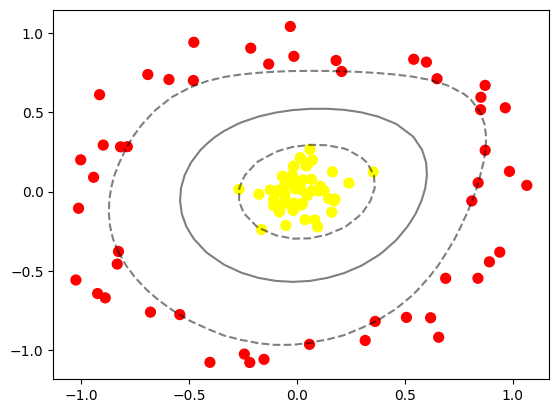

In [9]:
	plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
	plot_svc_decision_function(clf)
	plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
	            s=300, lw=1, facecolors='none')